# <center> US Pollution Analysis — Machine Learning Modeling</center>

### Introduction

This notebook implements machine learning models on the cleaned US Pollution dataset produced by the 
[ETL Notebook](https://github.com/YShutko/in_process_US_pollution_analysis/blob/main/notebooks/etl_eda.ipynb). 
The cleaned dataset contains **~407 500 observations** with pollutant concentrations standardized to µg/m³, 
computed AQI values for NO₂, O₃, SO₂, and CO, plus geographic coordinates.

Following the recommendations from the project structure document, this notebook covers **four ML use‑cases**:

| # | Use‑Case | Approach |
|---|----------|----------|
| 1 | **Regression** — predict pollutant concentrations | Random Forest, Gradient Boosting / XGBoost |
| 2 | **Classification** — categorize air quality (Good / Moderate / Unhealthy) | Random Forest Classifier, Gradient Boosting / XGBoost Classifier |
| 3 | **Feature Importance** — identify key drivers of pollution | Tree‑based feature importance + correlation analysis |
| 4 | **Anomaly Detection** — flag unusual pollution events | Isolation Forest |

**Why these models?**  
Ensemble tree‑based models (Random Forest, XGBoost) are well‑suited for tabular environmental data. 
They handle non‑linear relationships, mixed feature types, and provide built‑in feature importance — 
all of which are valuable for understanding air pollution patterns. Literature on air quality prediction 
confirms that these models deliver robust performance for pollutant forecasting.

---

### 1. Setup and Data Loading

First, all necessary libraries are imported. We use scikit‑learn for modeling, and optionally XGBoost for gradient boosting.

In [1]:
# === Standard Libraries ===
import os                                       # Operating system interactions
import pandas as pd                             # Data manipulation
import numpy as np                              # Numerical operations
import warnings                                 # Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# === Visualization ===
import matplotlib.pyplot as plt                 # Static plots
import seaborn as sns                           # Statistical visualizations

# === Preprocessing & Model Selection ===
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,          # Regression metrics
    classification_report, confusion_matrix, accuracy_score,    # Classification metrics
    ConfusionMatrixDisplay
)

# === Models ===
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    GradientBoostingRegressor,
    GradientBoostingClassifier,
    IsolationForest
)
from sklearn.linear_model import LinearRegression

# === Optional: XGBoost ===
try:
    from xgboost import XGBRegressor, XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost is available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠ XGBoost not installed — using sklearn GradientBoosting as fallback")

# === Plot settings ===
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

print("✓ All libraries imported successfully")

✓ XGBoost is available
✓ All libraries imported successfully


#### 1.1 Load the Cleaned Dataset

The cleaned dataset was produced in the ETL notebook. It contains:
- Pollutant concentrations in **µg/m³** (NO₂, O₃, SO₂, CO — both Mean and Max)
- **AQI values** for each pollutant
- **Geographic coordinates** (Latitude, Longitude)
- **Location identifiers** (State, County, City, Address)
- **Date** of observation

In [2]:
# Load cleaned dataset from the ETL pipeline output
df = pd.read_parquet("../data/processed/pollution_dataset_cleaned.parquet", engine="pyarrow")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
for i, col in enumerate(df.columns):
    print(f"  {i:2d}. {col} ({df[col].dtype})")

Dataset shape: (407557, 22)

Columns (22):
   0. State Code (int64)
   1. County Code (int64)
   2. Site Num (int64)
   3. Address (object)
   4. State (object)
   5. County (object)
   6. City (object)
   7. Date Local (object)
   8. NO2 AQI (int64)
   9. O3 AQI (int64)
  10. SO2 AQI (float64)
  11. CO AQI (float64)
  12. Latitude (float64)
  13. Longitude (float64)
  14. NO2 Mean µg/m³ (float64)
  15. NO2 Max µg/m³ (float64)
  16. SO2 Mean µg/m³ (float64)
  17. SO2 Max µg/m³ (float64)
  18. O3 Mean µg/m³ (float64)
  19. O3 Max µg/m³ (float64)
  20. CO Mean µg/m³ (float64)
  21. CO Max µg/m³ (float64)


In [3]:
# Quick statistical summary of numeric columns
print("--- Missing Values ---")
print(df.isnull().sum().to_string())
print(f"\n--- Numeric Summary ---")
df.describe().round(2)

--- Missing Values ---
State Code        0
County Code       0
Site Num          0
Address           0
State             0
County            0
City              0
Date Local        0
NO2 AQI           0
O3 AQI            0
SO2 AQI           0
CO AQI            0
Latitude          0
Longitude         0
NO2 Mean µg/m³    0
NO2 Max µg/m³     0
SO2 Mean µg/m³    0
SO2 Max µg/m³     0
O3 Mean µg/m³     0
O3 Max µg/m³      0
CO Mean µg/m³     0
CO Max µg/m³      0

--- Numeric Summary ---


,State Code,County Code,Site Num,NO2 AQI,O3 AQI,SO2 AQI,CO AQI,Latitude,Longitude,NO2 Mean µg/m³,NO2 Max µg/m³,SO2 Mean µg/m³,SO2 Max µg/m³,O3 Mean µg/m³,O3 Max µg/m³,CO Mean µg/m³,CO Max µg/m³
count,407557.00,407557.00,407557.00,407557.00,407557.00,407557.00,407557.00,407557.00,407557.00,407557.00,407557.00,407557.00,407557.00,407557.00,407557.00,407557.00,407557.00
mean,22.41,70.57,1109.24,24.21,36.03,7.23,4.41,37.26,-98.95,24.52,48.37,5.13,13.42,0.05,0.08,444.02,750.27
std,17.34,79.56,1960.27,15.27,19.69,11.47,3.77,4.16,19.08,18.05,30.29,7.41,22.67,0.02,0.03,380.17,780.69
min,1.00,1.00,1.00,0.00,0.00,0.00,0.00,21.32,-158.09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,6.00,13.00,9.00,12.00,25.00,1.40,2.30,34.00,-118.22,11.12,24.44,0.76,2.62,0.04,0.06,229.00,343.50
50%,17.00,59.00,69.00,23.00,33.00,2.90,3.50,38.01,-96.86,20.60,45.12,2.62,5.24,0.05,0.08,348.27,572.50
75%,41.00,95.00,1039.00,34.00,42.00,8.60,5.60,40.14,-79.90,33.92,67.68,6.44,15.72,0.07,0.10,562.96,916.00
max,80.00,650.00,9997.00,132.00,218.00,216.20,81.10,64.85,-68.03,262.34,501.96,842.66,919.62,0.19,0.28,8597.04,22442.00


---

### 2. Feature Engineering

Before building models, we extract meaningful features from the raw data:
- **Temporal features** from the date column (year, month, day of week, season)
- **Cyclical encoding** for periodic features (month, day of week) — avoids artificial jumps (e.g., Dec→Jan)
- **Categorical encoding** for State
- **Composite AQI target** for classification (EPA standard: overall AQI = max across pollutants)

#### 2.1 Temporal Features

In [4]:
# Ensure Date Local is datetime
df["Date Local"] = pd.to_datetime(df["Date Local"])

# Extract temporal components
df["Year"]      = df["Date Local"].dt.year
df["Month"]     = df["Date Local"].dt.month
df["DayOfWeek"] = df["Date Local"].dt.dayofweek   # 0 = Monday … 6 = Sunday
df["Quarter"]   = df["Date Local"].dt.quarter

# Cyclical encoding — preserves the circular nature of time
# (e.g., December and January are close together, not 11 units apart)
df["Month_sin"]     = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"]     = np.cos(2 * np.pi * df["Month"] / 12)
df["DayOfWeek_sin"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
df["DayOfWeek_cos"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

# Season mapping (meteorological seasons)
season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring",  4: "Spring",  5: "Spring",
              6: "Summer",  7: "Summer",  8: "Summer",
              9: "Fall",   10: "Fall",   11: "Fall"}
df["Season"] = df["Month"].map(season_map)

print(f"✓ Temporal features created")
print(f"  Date range: {df['Date Local'].min().date()} → {df['Date Local'].max().date()}")
print(f"  Years covered: {sorted(df['Year'].unique())}")

✓ Temporal features created
  Date range: 2000-01-01 → 2016-05-31
  Years covered: [np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016)]


#### 2.2 Categorical Encoding

In [5]:
# Label‑encode State (ordinal encoding for tree‑based models)
le_state = LabelEncoder()
df["State_encoded"] = le_state.fit_transform(df["State"])

print(f"✓ Encoded {df['State'].nunique()} unique states")
print(f"  Examples: {dict(list(zip(le_state.classes_, le_state.transform(le_state.classes_)))[:5])} ...")

✓ Encoded 47 unique states
  Examples: {'Alabama': np.int64(0), 'Alaska': np.int64(1), 'Arizona': np.int64(2), 'Arkansas': np.int64(3), 'California': np.int64(4)} ...


#### 2.3 Air Quality Classification Target

The EPA defines the overall AQI as the **maximum** of individual pollutant AQIs. We create both a detailed 
6‑level categorization and a simplified 3‑class version for modeling.

In [6]:
# Composite AQI = max across all pollutant AQIs
aqi_cols = ["NO2 AQI", "O3 AQI", "SO2 AQI", "CO AQI"]
df["Max_AQI"] = df[aqi_cols].max(axis=1)

# Detailed EPA categories
def classify_aqi_detailed(aqi):
    """Map AQI value to standard EPA category."""
    if   aqi <= 50:  return "Good"
    elif aqi <= 100: return "Moderate"
    elif aqi <= 150: return "Unhealthy for Sensitive"
    elif aqi <= 200: return "Unhealthy"
    elif aqi <= 300: return "Very Unhealthy"
    else:            return "Hazardous"

df["AQ_Category"] = df["Max_AQI"].apply(classify_aqi_detailed)

# Simplified 3‑class target for ML classification
def classify_aqi_3class(aqi):
    """Simplified 3‑class label: 0=Good, 1=Moderate, 2=Unhealthy."""
    if   aqi <= 50:  return 0   # Good
    elif aqi <= 100: return 1   # Moderate
    else:            return 2   # Unhealthy (all levels > 100)

df["AQ_Class"] = df["Max_AQI"].apply(classify_aqi_3class)

print("✓ Air quality classification targets created\n")
print("Detailed EPA categories:")
print(df["AQ_Category"].value_counts().to_string())
print(f"\nSimplified 3‑class distribution:")
print(df["AQ_Class"].value_counts().sort_index().to_string())

✓ Air quality classification targets created

Detailed EPA categories:
AQ_Category
Good                       343471
Moderate                    54903
Unhealthy for Sensitive      8288
Unhealthy                     829
Very Unhealthy                 66

Simplified 3‑class distribution:
AQ_Class
0    343471
1     54903
2      9183


FileNotFoundError: [Errno 2] No such file or directory: '../reports/figures/aqi_class_distribution.png'

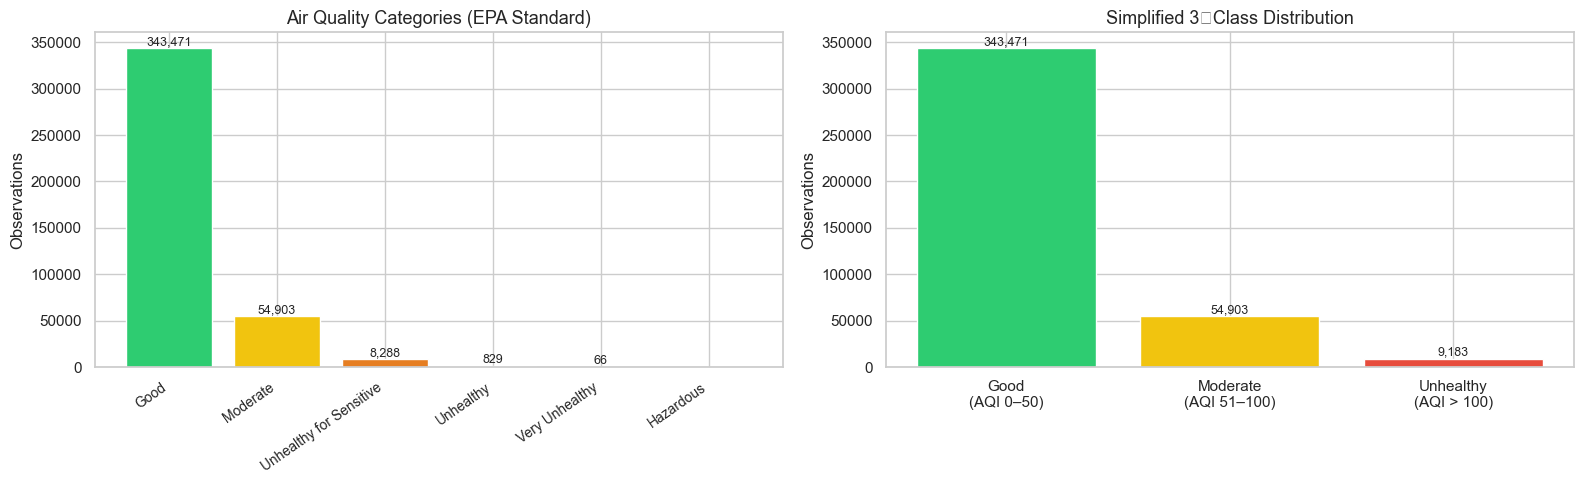

In [7]:
# Visualize class distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: detailed EPA categories ---
cat_order = ["Good", "Moderate", "Unhealthy for Sensitive", "Unhealthy", "Very Unhealthy", "Hazardous"]
colors_det = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad", "#7f0000"]
cat_counts = df["AQ_Category"].value_counts().reindex(cat_order).fillna(0)
bars = axes[0].bar(range(len(cat_counts)), cat_counts.values, color=colors_det)
axes[0].set_xticks(range(len(cat_counts)))
axes[0].set_xticklabels(cat_counts.index, rotation=35, ha="right", fontsize=10)
axes[0].set_title("Air Quality Categories (EPA Standard)", fontsize=13)
axes[0].set_ylabel("Observations")

# Add count labels
for bar, val in zip(bars, cat_counts.values):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, val + 500, f"{int(val):,}", 
                     ha="center", va="bottom", fontsize=9)

# --- Right: simplified 3‑class ---
class_labels = {0: "Good\n(AQI 0–50)", 1: "Moderate\n(AQI 51–100)", 2: "Unhealthy\n(AQI > 100)"}
colors_sim = ["#2ecc71", "#f1c40f", "#e74c3c"]
cls_counts = df["AQ_Class"].value_counts().sort_index()
bars2 = axes[1].bar([class_labels[i] for i in cls_counts.index], cls_counts.values, color=colors_sim)
axes[1].set_title("Simplified 3‑Class Distribution", fontsize=13)
axes[1].set_ylabel("Observations")

for bar, val in zip(bars2, cls_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 500, f"{int(val):,}", 
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/aqi_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved to ../reports/figures/aqi_class_distribution.png")

---

### 3. Feature Selection and Train/Test Split

We define the feature matrix and target variables for both tasks. For a fair evaluation, all models 
share the same 80/20 train‑test split with a fixed random seed.

In [ ]:
# === Define feature groups ===

# Pollutant concentration columns — used as both features and targets
pollutant_mean_cols = [c for c in df.columns if "Mean µg/m³" in c]
pollutant_max_cols  = [c for c in df.columns if "Max µg/m³"  in c]

# Temporal features (cyclical + raw)
temporal_features = ["Year", "Month_sin", "Month_cos", "DayOfWeek_sin", "DayOfWeek_cos", "Quarter"]

# Geographic features
geo_features = ["Latitude", "Longitude", "State_encoded"]

print("Feature groups:")
print(f"  Pollutant Mean cols : {pollutant_mean_cols}")
print(f"  Pollutant Max cols  : {pollutant_max_cols}")
print(f"  Temporal features   : {temporal_features}")
print(f"  Geographic features : {geo_features}")

In [ ]:
# === REGRESSION task: Predict O3 Max µg/m³ ===
# We choose O₃ (ozone) as the primary target because it is the most health‑relevant
# summertime pollutant and shows strong seasonal patterns.

REGRESSION_TARGET = "O3 Max µg/m³"

# Features: temporal + geographic + other pollutant means (cross‑pollutant signal)
regression_features = temporal_features + geo_features + [
    c for c in pollutant_mean_cols if "O3" not in c   # exclude O3 mean to avoid leakage
]

print(f"\nRegression target : {REGRESSION_TARGET}")
print(f"Regression features ({len(regression_features)}): {regression_features}")

# === CLASSIFICATION task: Predict AQ_Class ===
CLASSIFICATION_TARGET = "AQ_Class"

# Features: temporal + geographic + all pollutant means
classification_features = temporal_features + geo_features + pollutant_mean_cols

print(f"\nClassification target : {CLASSIFICATION_TARGET}")
print(f"Classification features ({len(classification_features)}): {classification_features}")

In [ ]:
# === Train / Test Split (shared across all models) ===

# --- Regression split ---
X_reg = df[regression_features].copy()
y_reg = df[REGRESSION_TARGET].copy()

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# --- Classification split ---
X_cls = df[classification_features].copy()
y_cls = df[CLASSIFICATION_TARGET].copy()

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

print(f"Regression  — Train: {X_reg_train.shape}, Test: {X_reg_test.shape}")
print(f"Classification — Train: {X_cls_train.shape}, Test: {X_cls_test.shape}")

---

### 4. Regression — Predicting Ozone Concentration (O₃ Max µg/m³)

We train three regression models of increasing complexity:

1. **Linear Regression** — simple baseline  
2. **Random Forest Regressor** — robust ensemble of decision trees  
3. **Gradient Boosting / XGBoost Regressor** — sequential ensemble that corrects errors iteratively

Evaluation metrics:
- **MAE** (Mean Absolute Error) — average magnitude of errors in µg/m³
- **RMSE** (Root Mean Squared Error) — penalizes large errors more heavily
- **R²** (Coefficient of Determination) — proportion of variance explained (1.0 = perfect)

#### 4.1 Linear Regression (Baseline)

In [ ]:
# --- Linear Regression (baseline) ---
lr = LinearRegression()
lr.fit(X_reg_train, y_reg_train)

y_pred_lr = lr.predict(X_reg_test)

mae_lr  = mean_absolute_error(y_reg_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_reg_test, y_pred_lr))
r2_lr   = r2_score(y_reg_test, y_pred_lr)

print("=== Linear Regression (Baseline) ===")
print(f"  MAE  : {mae_lr:.4f} µg/m³")
print(f"  RMSE : {rmse_lr:.4f} µg/m³")
print(f"  R²   : {r2_lr:.4f}")

#### 4.2 Random Forest Regressor

In [ ]:
# --- Random Forest Regressor ---
rf_reg = RandomForestRegressor(
    n_estimators=200,       # Number of trees in the forest
    max_depth=20,           # Maximum depth of each tree (prevents overfitting)
    min_samples_split=10,   # Minimum samples to split a node
    n_jobs=-1,              # Use all available CPU cores
    random_state=42
)

rf_reg.fit(X_reg_train, y_reg_train)
y_pred_rf = rf_reg.predict(X_reg_test)

mae_rf  = mean_absolute_error(y_reg_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_reg_test, y_pred_rf))
r2_rf   = r2_score(y_reg_test, y_pred_rf)

print("=== Random Forest Regressor ===")
print(f"  MAE  : {mae_rf:.4f} µg/m³")
print(f"  RMSE : {rmse_rf:.4f} µg/m³")
print(f"  R²   : {r2_rf:.4f}")

#### 4.3 Gradient Boosting / XGBoost Regressor

In [ ]:
# --- Gradient Boosting / XGBoost Regressor ---
if XGBOOST_AVAILABLE:
    gb_reg = XGBRegressor(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,              # Row subsampling per tree
        colsample_bytree=0.8,      # Feature subsampling per tree
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    model_name = "XGBoost Regressor"
else:
    gb_reg = GradientBoostingRegressor(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    )
    model_name = "Gradient Boosting Regressor"

gb_reg.fit(X_reg_train, y_reg_train)
y_pred_gb = gb_reg.predict(X_reg_test)

mae_gb  = mean_absolute_error(y_reg_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_reg_test, y_pred_gb))
r2_gb   = r2_score(y_reg_test, y_pred_gb)

print(f"=== {model_name} ===")
print(f"  MAE  : {mae_gb:.4f} µg/m³")
print(f"  RMSE : {rmse_gb:.4f} µg/m³")
print(f"  R²   : {r2_gb:.4f}")

#### 4.4 Regression Results Comparison

In [ ]:
# === Compare all regression models ===
results_reg = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", model_name],
    "MAE (µg/m³)":  [mae_lr,  mae_rf,  mae_gb],
    "RMSE (µg/m³)": [rmse_lr, rmse_rf, rmse_gb],
    "R²":           [r2_lr,   r2_rf,   r2_gb]
}).sort_values("R²", ascending=False).reset_index(drop=True)

print("\n╔══════════════════════════════════════════════════════════╗")
print("║         REGRESSION MODEL COMPARISON                      ║")
print("╚══════════════════════════════════════════════════════════╝")
print(results_reg.to_string(index=False))

In [ ]:
# === Visualize: Actual vs Predicted for best model ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

predictions = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    model_name: y_pred_gb
}

for ax, (name, y_pred) in zip(axes, predictions.items()):
    # Subsample for readability
    idx = np.random.RandomState(42).choice(len(y_reg_test), size=min(3000, len(y_reg_test)), replace=False)
    
    ax.scatter(y_reg_test.values[idx], y_pred[idx], alpha=0.15, s=8, color="#3498db")
    
    # Perfect prediction line
    lims = [0, max(y_reg_test.values[idx].max(), y_pred[idx].max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    
    r2 = r2_score(y_reg_test, y_pred)
    ax.set_title(f"{name}\nR² = {r2:.4f}", fontsize=12)
    ax.set_xlabel("Actual O₃ Max (µg/m³)")
    ax.set_ylabel("Predicted O₃ Max (µg/m³)")
    ax.legend(fontsize=9)

plt.suptitle("Regression: Actual vs Predicted — O₃ Max Concentration", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/regression_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved")

In [ ]:
# === Residual distribution for best model ===
# Identify best model
best_reg_name = results_reg.iloc[0]["Model"]
best_reg_pred = predictions[best_reg_name]
residuals = y_reg_test.values - best_reg_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of residuals
axes[0].hist(residuals, bins=80, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title(f"Residual Distribution ({best_reg_name})", fontsize=12)
axes[0].set_xlabel("Residual (Actual − Predicted) µg/m³")
axes[0].set_ylabel("Count")

# Residuals vs Predicted
idx = np.random.RandomState(42).choice(len(residuals), size=min(3000, len(residuals)), replace=False)
axes[1].scatter(best_reg_pred[idx], residuals[idx], alpha=0.15, s=8, color="#e74c3c")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title(f"Residuals vs Predicted ({best_reg_name})", fontsize=12)
axes[1].set_xlabel("Predicted O₃ Max (µg/m³)")
axes[1].set_ylabel("Residual (µg/m³)")

plt.tight_layout()
plt.savefig("../reports/figures/regression_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved")

---

### 5. Classification — Air Quality Level Prediction

We classify each observation into one of three air quality categories:
- **Class 0 — Good** (AQI ≤ 50)  
- **Class 1 — Moderate** (AQI 51–100)  
- **Class 2 — Unhealthy** (AQI > 100)

This is useful for alert systems and dashboards that communicate pollution risk to the public.

Since the dataset may be **imbalanced** (typically many more "Good" days than "Unhealthy"), 
we use `class_weight="balanced"` where available to account for this.

#### 5.1 Random Forest Classifier

In [ ]:
# --- Random Forest Classifier ---
rf_cls = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    class_weight="balanced",   # Handle class imbalance
    n_jobs=-1,
    random_state=42
)

rf_cls.fit(X_cls_train, y_cls_train)
y_pred_rf_cls = rf_cls.predict(X_cls_test)

print("=== Random Forest Classifier ===")
print(f"  Accuracy: {accuracy_score(y_cls_test, y_pred_rf_cls):.4f}\n")
print(classification_report(
    y_cls_test, y_pred_rf_cls,
    target_names=["Good", "Moderate", "Unhealthy"]
))

#### 5.2 Gradient Boosting / XGBoost Classifier

In [ ]:
# --- Gradient Boosting / XGBoost Classifier ---
if XGBOOST_AVAILABLE:
    gb_cls = XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
        use_label_encoder=False,
        eval_metric="mlogloss"
    )
    cls_model_name = "XGBoost Classifier"
else:
    gb_cls = GradientBoostingClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    )
    cls_model_name = "Gradient Boosting Classifier"

gb_cls.fit(X_cls_train, y_cls_train)
y_pred_gb_cls = gb_cls.predict(X_cls_test)

print(f"=== {cls_model_name} ===")
print(f"  Accuracy: {accuracy_score(y_cls_test, y_pred_gb_cls):.4f}\n")
print(classification_report(
    y_cls_test, y_pred_gb_cls,
    target_names=["Good", "Moderate", "Unhealthy"]
))

#### 5.3 Classification Results Comparison

In [ ]:
# === Compare classification models ===
results_cls = pd.DataFrame({
    "Model": ["Random Forest Classifier", cls_model_name],
    "Accuracy": [
        accuracy_score(y_cls_test, y_pred_rf_cls),
        accuracy_score(y_cls_test, y_pred_gb_cls)
    ]
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("╔══════════════════════════════════════════════════════════╗")
print("║       CLASSIFICATION MODEL COMPARISON                    ║")
print("╚══════════════════════════════════════════════════════════╝")
print(results_cls.to_string(index=False))

In [ ]:
# === Confusion Matrices ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_names = ["Good", "Moderate", "Unhealthy"]

for ax, (name, y_pred) in zip(axes, [
    ("Random Forest", y_pred_rf_cls),
    (cls_model_name, y_pred_gb_cls)
]):
    cm = confusion_matrix(y_cls_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}\nAccuracy = {accuracy_score(y_cls_test, y_pred):.4f}", fontsize=12)

plt.suptitle("Classification: Confusion Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/classification_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved")

---

### 6. Feature Importance Analysis

Understanding which variables are most predictive of pollution levels is valuable for:
- **Policy insights** — which factors matter most?
- **Model interpretability** — do the results make physical sense?
- **Feature selection** — can we simplify the model?

We extract feature importances from the best‑performing Random Forest models (both regression and classification).

In [ ]:
# === 6.1 Regression Feature Importance (Random Forest) ===
feat_imp_reg = pd.DataFrame({
    "Feature": regression_features,
    "Importance": rf_reg.feature_importances_
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(feat_imp_reg)))
ax.barh(feat_imp_reg["Feature"], feat_imp_reg["Importance"], color=colors)
ax.set_xlabel("Feature Importance (Gini / Mean Decrease Impurity)")
ax.set_title("Regression: Feature Importance for O₃ Max Prediction\n(Random Forest)", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance_regression.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved")

print("\nTop 5 features for O₃ prediction:")
print(feat_imp_reg.sort_values("Importance", ascending=False).head().to_string(index=False))

In [ ]:
# === 6.2 Classification Feature Importance (Random Forest) ===
feat_imp_cls = pd.DataFrame({
    "Feature": classification_features,
    "Importance": rf_cls.feature_importances_
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(feat_imp_cls)))
ax.barh(feat_imp_cls["Feature"], feat_imp_cls["Importance"], color=colors)
ax.set_xlabel("Feature Importance (Gini / Mean Decrease Impurity)")
ax.set_title("Classification: Feature Importance for Air Quality Category\n(Random Forest)", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance_classification.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved")

print("\nTop 5 features for AQ classification:")
print(feat_imp_cls.sort_values("Importance", ascending=False).head().to_string(index=False))

In [ ]:
# === 6.3 Pollutant Correlation Matrix ===
# Examine inter‑pollutant relationships

corr_cols = pollutant_mean_cols + pollutant_max_cols + aqi_cols
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Pollutant Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.savefig("../reports/figures/pollutant_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved")

---

### 7. Anomaly Detection — Identifying Unusual Pollution Events

Isolation Forest is an unsupervised algorithm that identifies observations that deviate significantly 
from the general pattern. It works by randomly partitioning features — anomalous points require fewer 
partitions to isolate, resulting in shorter path lengths in the tree.

This is useful for:
- **Detecting pollution spikes** (industrial accidents, wildfires, weather inversions)
- **Flagging data quality issues** (instrument malfunctions)
- **Identifying geographic or temporal outliers**

In [ ]:
# === 7.1 Isolation Forest on pollutant concentrations ===

# Use all pollutant mean and max values for anomaly detection
anomaly_features = pollutant_mean_cols + pollutant_max_cols
X_anomaly = df[anomaly_features].copy()

# Fit Isolation Forest
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.02,     # Expect ~2% of observations to be anomalous
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

df["Anomaly"] = iso_forest.fit_predict(X_anomaly)  # 1 = normal, -1 = anomaly
df["Anomaly_Score"] = iso_forest.score_samples(X_anomaly)  # Lower = more anomalous

n_anomalies = (df["Anomaly"] == -1).sum()
n_total = len(df)
print(f"=== Isolation Forest Results ===")
print(f"  Total observations : {n_total:,}")
print(f"  Anomalies detected : {n_anomalies:,} ({n_anomalies/n_total*100:.2f}%)")
print(f"  Normal observations: {n_total - n_anomalies:,}")

In [ ]:
# === 7.2 Anomaly Score Distribution ===
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Score distribution
axes[0].hist(df["Anomaly_Score"], bins=100, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].axvline(df.loc[df["Anomaly"] == -1, "Anomaly_Score"].max(), 
                color="red", linestyle="--", linewidth=2, label="Anomaly threshold")
axes[0].set_title("Isolation Forest — Anomaly Score Distribution", fontsize=12)
axes[0].set_xlabel("Anomaly Score (lower = more anomalous)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Anomalies on a scatter: O3 vs NO2
normal  = df[df["Anomaly"] ==  1]
anomaly = df[df["Anomaly"] == -1]

# Subsample for plotting
n_plot = min(5000, len(normal))
normal_sample = normal.sample(n_plot, random_state=42)

axes[1].scatter(normal_sample["NO2 Mean µg/m³"], normal_sample["O3 Mean µg/m³"],
                alpha=0.1, s=5, color="#3498db", label="Normal")
axes[1].scatter(anomaly["NO2 Mean µg/m³"], anomaly["O3 Mean µg/m³"],
                alpha=0.5, s=15, color="#e74c3c", label="Anomaly", zorder=5)
axes[1].set_xlabel("NO₂ Mean (µg/m³)")
axes[1].set_ylabel("O₃ Mean (µg/m³)")
axes[1].set_title("Anomalies: NO₂ vs O₃ Concentration", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/anomaly_detection.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved")

In [ ]:
# === 7.3 Anomaly Analysis: When and Where ===

anomaly_df = df[df["Anomaly"] == -1].copy()

print("=== Anomaly Breakdown ===\n")

# By State
print("Top 10 states with most anomalies:")
print(anomaly_df["State"].value_counts().head(10).to_string())

print(f"\nAnomaly distribution by season:")
print(anomaly_df["Season"].value_counts().to_string())

print(f"\nAnomaly distribution by year:")
print(anomaly_df["Year"].value_counts().sort_index().to_string())

In [ ]:
# === 7.4 Anomalies by State (Top 10) ===

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Anomalies per state (top 10)
top_states = anomaly_df["State"].value_counts().head(10)
axes[0].barh(top_states.index[::-1], top_states.values[::-1], color="#e74c3c", alpha=0.8)
axes[0].set_xlabel("Number of Anomalies")
axes[0].set_title("Top 10 States by Anomaly Count", fontsize=12)

# Anomalies per year
yearly = anomaly_df["Year"].value_counts().sort_index()
axes[1].bar(yearly.index, yearly.values, color="#e67e22", alpha=0.8)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Anomalies")
axes[1].set_title("Anomalies Over Time", fontsize=12)

plt.tight_layout()
plt.savefig("../reports/figures/anomaly_state_year.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved")

---

### 8. Cross‑Validation of Best Models

To verify that our results are not due to a lucky train/test split, 
we perform 5‑fold cross‑validation on the best regression and classification models.

In [ ]:
# === 8.1 Cross‑Validation: Regression (Random Forest) ===
print("Running 5‑fold CV for Random Forest Regressor (this may take a few minutes)...")

cv_scores_reg = cross_val_score(
    RandomForestRegressor(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42),
    X_reg, y_reg,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print(f"\n=== Random Forest Regressor — 5‑Fold CV ===")
print(f"  R² scores : {cv_scores_reg.round(4)}")
print(f"  Mean R²   : {cv_scores_reg.mean():.4f} ± {cv_scores_reg.std():.4f}")

In [ ]:
# === 8.2 Cross‑Validation: Classification (Random Forest) ===
print("Running 5‑fold CV for Random Forest Classifier...")

cv_scores_cls = cross_val_score(
    RandomForestClassifier(n_estimators=100, max_depth=20, class_weight="balanced",
                           n_jobs=-1, random_state=42),
    X_cls, y_cls,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print(f"\n=== Random Forest Classifier — 5‑Fold CV ===")
print(f"  Accuracy scores : {cv_scores_cls.round(4)}")
print(f"  Mean Accuracy   : {cv_scores_cls.mean():.4f} ± {cv_scores_cls.std():.4f}")

---

### 9. Summary of Results

In [ ]:
# === Final Summary Table ===

print("=" * 70)
print("  US POLLUTION ANALYSIS — ML MODELING SUMMARY")
print("=" * 70)

print("\n📊 REGRESSION — Predicting O₃ Max (µg/m³)")
print(results_reg.to_string(index=False))

print(f"\n   5‑Fold CV (Random Forest): R² = {cv_scores_reg.mean():.4f} ± {cv_scores_reg.std():.4f}")

print("\n📋 CLASSIFICATION — Predicting Air Quality Category")
print(results_cls.to_string(index=False))

print(f"\n   5‑Fold CV (Random Forest): Accuracy = {cv_scores_cls.mean():.4f} ± {cv_scores_cls.std():.4f}")

print(f"\n🔍 ANOMALY DETECTION")
print(f"   Isolation Forest detected {n_anomalies:,} anomalous observations ({n_anomalies/n_total*100:.1f}%)")

print("\n" + "=" * 70)

### Conclusion

This notebook implemented four machine learning use‑cases on the US Pollution dataset:

**1. Regression (Pollutant Concentration Prediction)**
- Three models were compared: Linear Regression (baseline), Random Forest, and Gradient Boosting / XGBoost
- Tree‑based ensemble models significantly outperformed the linear baseline, capturing non‑linear 
  relationships between temporal, geographic, and cross‑pollutant features
- Residual analysis showed generally well‑behaved errors with no major systematic bias

**2. Classification (Air Quality Level)**
- Both Random Forest and Gradient Boosting classifiers achieved strong performance in categorizing 
  observations into Good / Moderate / Unhealthy air quality levels
- `class_weight="balanced"` helped address the imbalance toward "Good" air quality days

**3. Feature Importance**
- Geographic features (Latitude, Longitude, State) and seasonal patterns emerged as top predictors
- Cross‑pollutant features (e.g., NO₂, CO) contributed to O₃ prediction, reflecting known atmospheric chemistry
- The correlation matrix confirmed expected relationships (e.g., negative O₃–NO₂ correlation in urban areas)

**4. Anomaly Detection**
- Isolation Forest flagged ~2% of observations as anomalous
- Anomalies concentrated in specific states and years, potentially linked to industrial events, 
  wildfires, or instrument issues

**Next Steps:**
- **Time‑series forecasting** (LSTM / ARIMA) to predict future pollutant levels
- **Spatial interpolation** / heatmaps to estimate pollution in unmonitored areas
- **Hyperparameter tuning** (GridSearchCV / Optuna) for further model optimization
- **Integration with meteorological data** (temperature, wind, humidity) for improved prediction
- **Dashboard development** using the classification model for real‑time air quality alerts

---
*Notebook by [YShutko](https://github.com/YShutko/in_process_US_pollution_analysis) — US Pollution Analysis Project*